In [1]:
# Fix sys path to find modules in the project
import sys
sys.path.append("/Users/gccasini/GitHub/diplomatrixbr-eval")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
from scripts.utils import get_mean
from matplotlib import pyplot as plt
import yaml
import textwrap

In [3]:
filepath = "/Users/gccasini/GitHub/diplomatrixbr-eval/prompt_testing/sheets/sabia_p7-12.csv"

df_eval = get_mean(filepath)
df_eval[:24]

,judge,versao,prompt,temp,redacao,nota_final,1A,1B,1C,CGPL,num_errors,faixa
0,sabia-3.1,1,7,0.0,1,54.0000,9.0000,9.0000,18.0000,18.0000,0.0000,NaN
1,sabia-3.1,1,7,0.5,1,52.6333,8.6667,8.6667,18.0000,17.3000,2.3333,NaN
2,sabia-3.1,1,7,0.9,1,51.6333,8.6667,9.0000,17.3333,16.6333,2.3333,NaN
3,sabia-3.1,1,8,0.0,1,55.7500,NaN,NaN,NaN,NaN,0.0000,NaN
4,sabia-3.1,1,8,0.5,1,57.2500,NaN,NaN,NaN,NaN,0.3333,NaN
5,sabia-3.1,1,8,0.9,1,56.8333,NaN,NaN,NaN,NaN,0.6667,NaN
6,sabia-3.1,1,9,0.0,1,NaN,NaN,NaN,NaN,NaN,0.0000,50.0000
7,sabia-3.1,1,9,0.5,1,NaN,NaN,NaN,NaN,NaN,0.0000,50.0000
8,sabia-3.1,1,9,0.9,1,NaN,NaN,NaN,NaN,NaN,0.0000,53.3333
9,sabia-3.1,1,10,0.0,1,54.0000,9.0000,9.0000,18.0000,18.0000,0.0000,NaN


## Distribuição de Notas

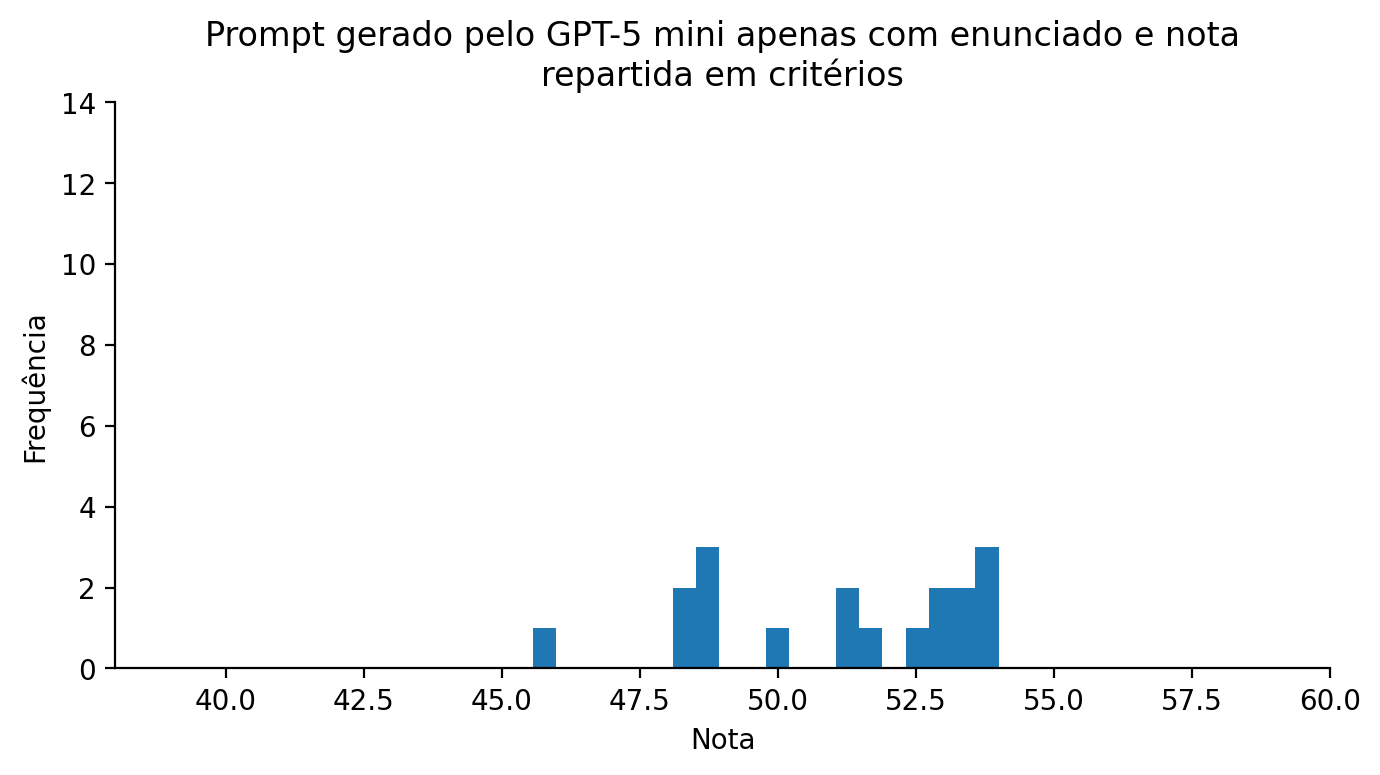

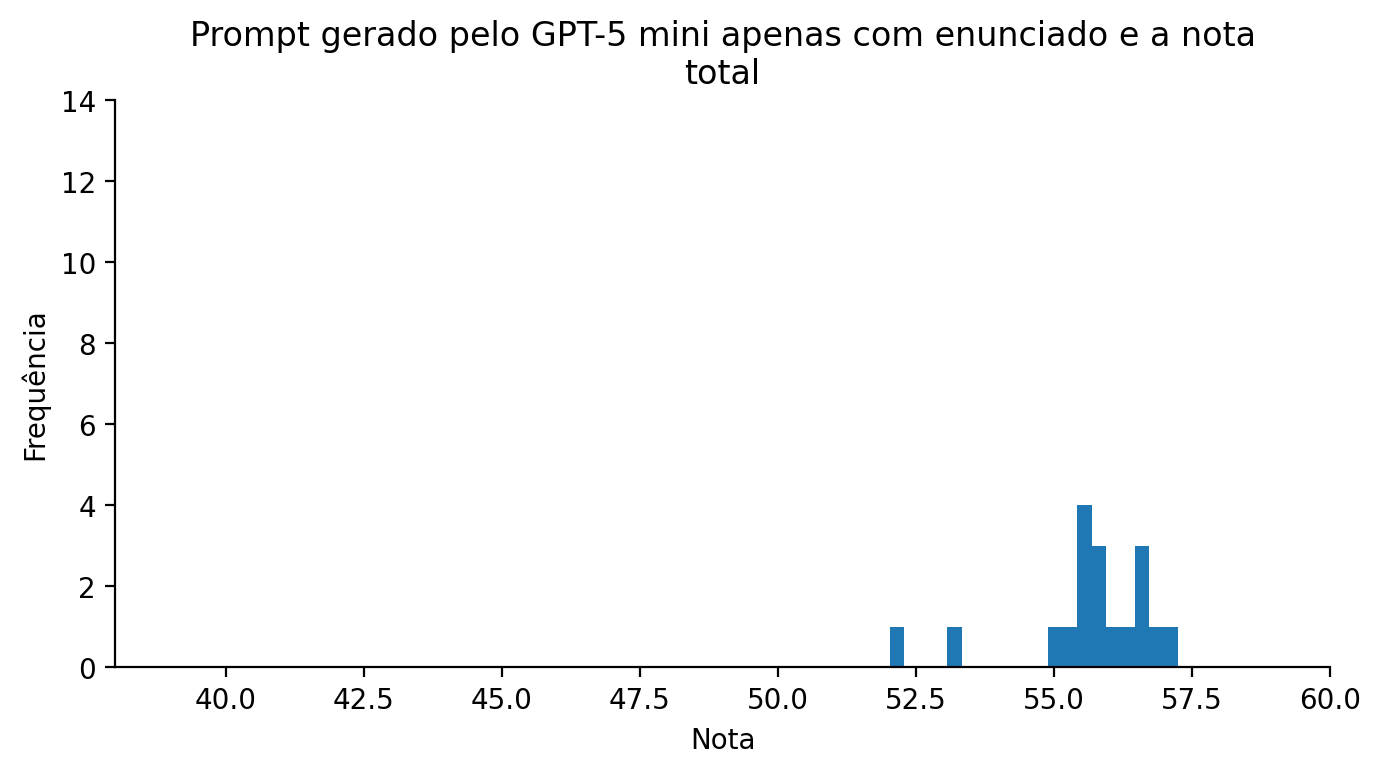

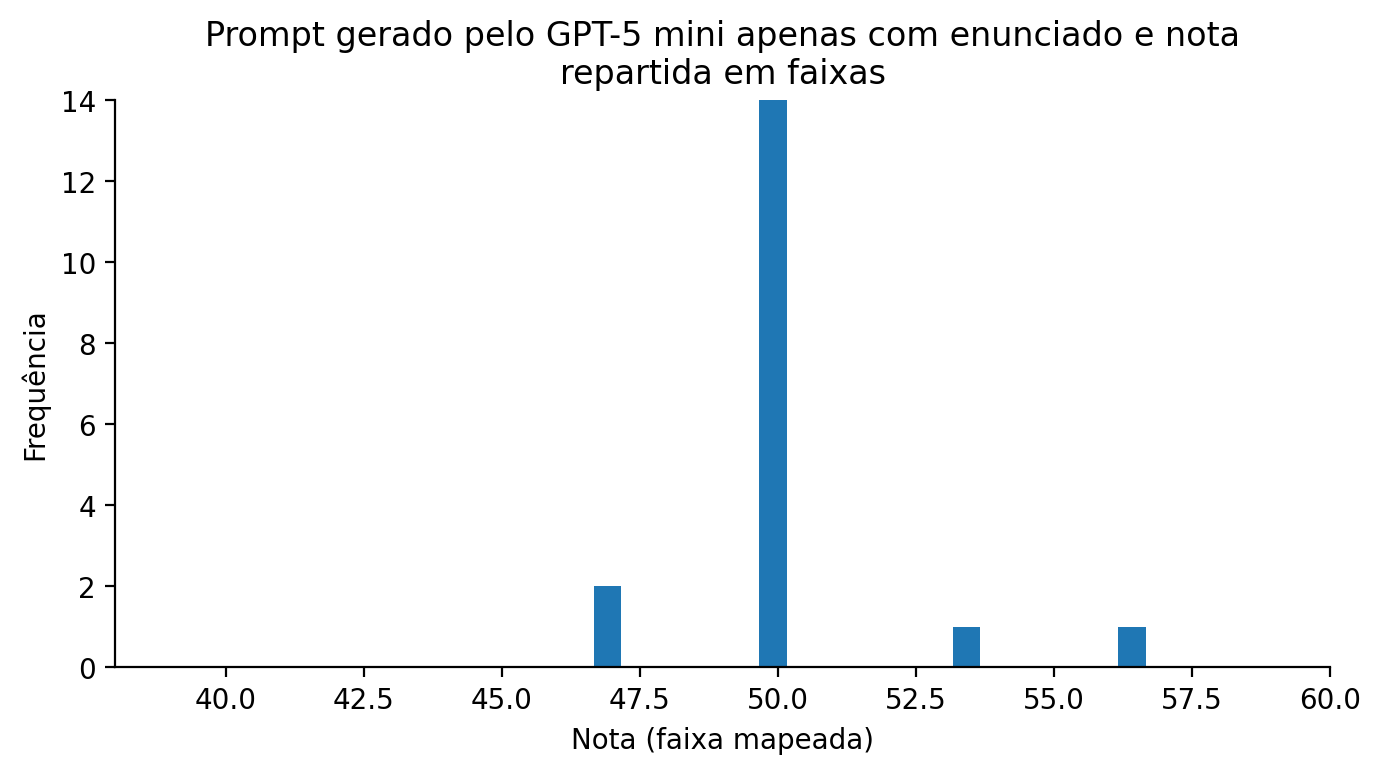

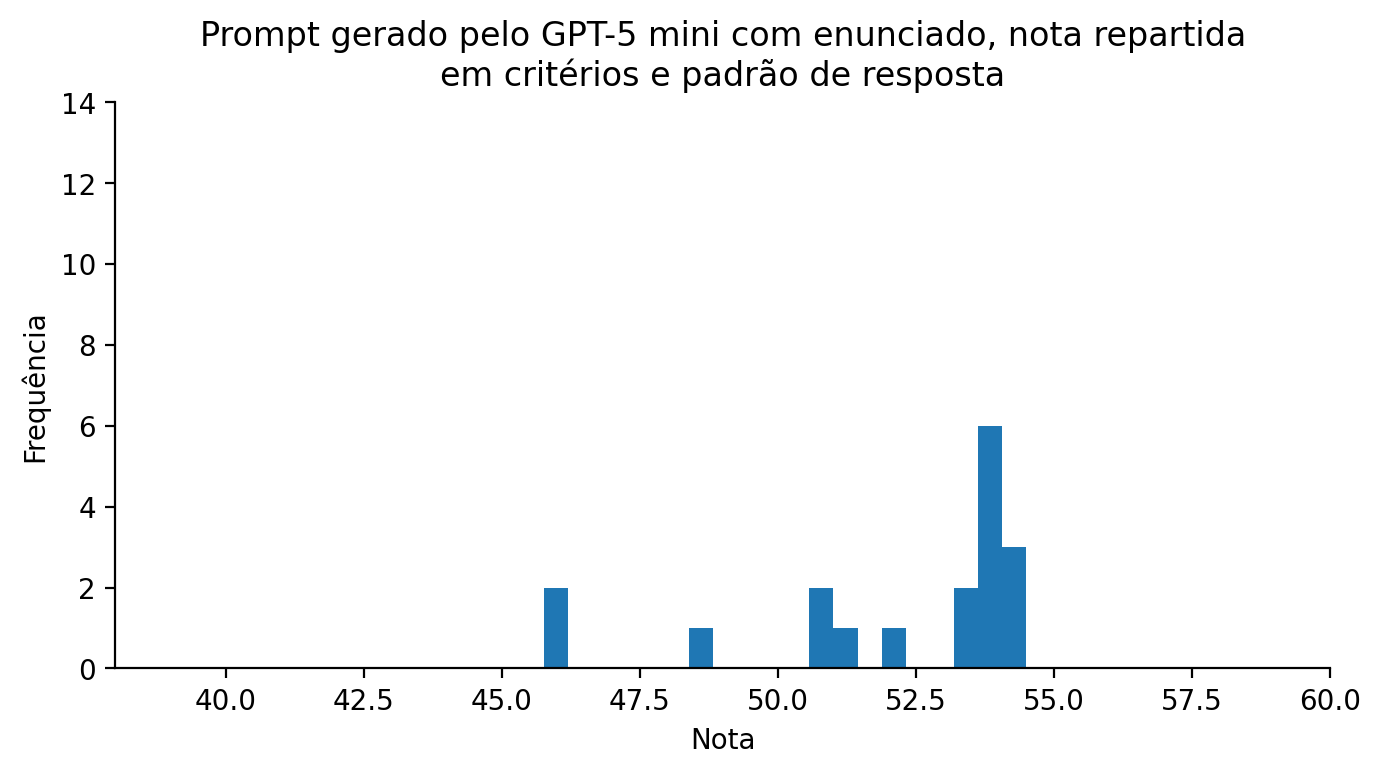

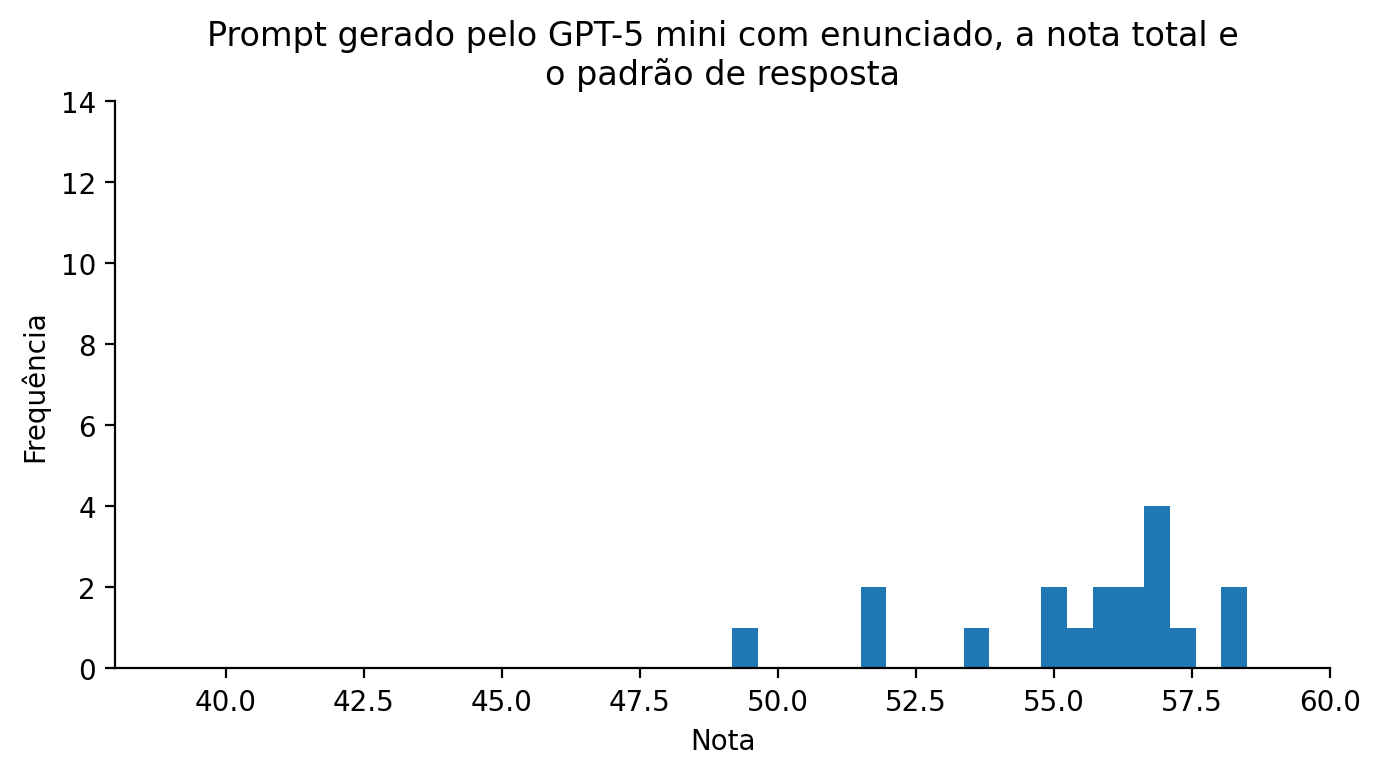

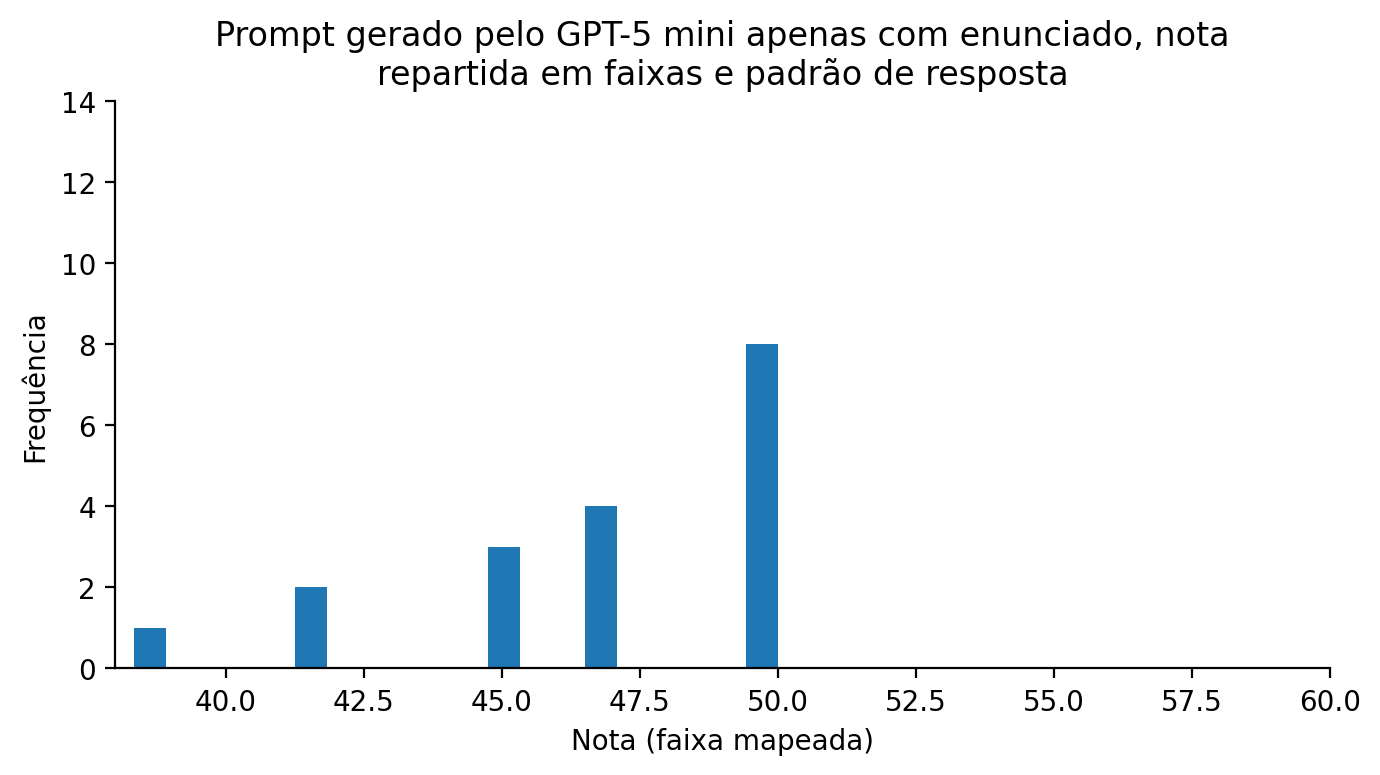

In [4]:
with open("/Users/gccasini/GitHub/diplomatrixbr-eval/prompt_testing/prompts.yaml", 'r', encoding='utf-8') as file:
    prompts_yaml = yaml.safe_load(file)
    prompts = prompts_yaml['prompts']


for i in [7, 8, 9, 10, 11, 12]:

    subset = df_eval[df_eval['prompt'] == i]
    prompt_description = "\n".join(textwrap.wrap(prompts[i+1]["description"], width=60))
    plt.figure(figsize=(7, 4))

    if i in [9, 12]:
        subset['faixa'].plot(
            kind='hist',
            bins=20,
            title=prompt_description,
            xlabel="Nota (faixa mapeada)",
            ylabel="Frequência"
        )
    else:
        subset['nota_final'].plot(
            kind='hist',
            bins=20,
            title=prompt_description,
            xlabel="Nota",
            ylabel="Frequência"
        )

    plt.xlim(38, 60)
    plt.ylim(0, 14)
    ax = plt.gca()
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()
